In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [62]:
def get_price_plots(FILENAME: str, day: int) -> None:
    df = pd.read_csv(FILENAME, delimiter=';')
    root = df[df['product'] == 'INTARIAN_PEPPER_ROOT']
    osmium = df[df['product'] == 'ASH_COATED_OSMIUM']
    
    price_cols = ['bid_price_1', 'ask_price_1', 'mid_price']
    for col in price_cols:
        osmium[col] = osmium[col].replace(0, pd.NA)
        root[col] = root[col].replace(0, pd.NA)
    
    osmium[price_cols] = osmium[osmium.columns.intersection(price_cols)].ffill()
    root[price_cols] = root[root.columns.intersection(price_cols)].ffill()

    fig, ax = plt.subplots(figsize=(8, 5))
    plt.title(f'Day {day} Root Prices')
    ax.grid()
    ax.plot(root['timestamp'], root['bid_price_1'], color='red', label='Root Bid Price 1', alpha=0.5)

    ax.plot(root['timestamp'], root['ask_price_1'], color='green', label='Root Ask Price 1', alpha=0.5)

    ax.plot(root['timestamp'], root['mid_price'], linestyle='dashed', color='grey', label='Root Mid Price')
    plt.legend(loc='lower right')

    fig, ax = plt.subplots(figsize=(8, 5))
    plt.title(f'Day {day} Osmium Prices')
    ax.grid()
    ax.plot(osmium['timestamp'], osmium['bid_price_1'], color='red', label='Osmium Bid Price 1', alpha=0.5)

    ax.plot(osmium['timestamp'], osmium['ask_price_1'], color='green', label='Osmium Ask Price 1', alpha=0.5)

    ax.plot(osmium['timestamp'], osmium['mid_price'], linestyle='dashed', color='grey', label='Osmium Mid Price')
    plt.legend(loc='lower right')

C:\Users\wfpin\AppData\Local\Temp\ipykernel_38340\4243613686.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  osmium[col] = osmium[col].replace(0, pd.NA)
C:\Users\wfpin\AppData\Local\Temp\ipykernel_38340\4243613686.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  root[col] = root[col].replace(0, pd.NA)
C:\Users\wfpin\AppData\Local\Temp\ipykernel_38340\4243613686.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call resu

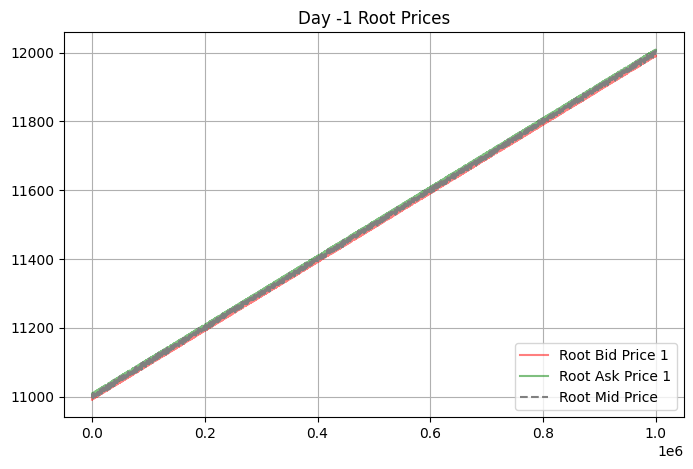

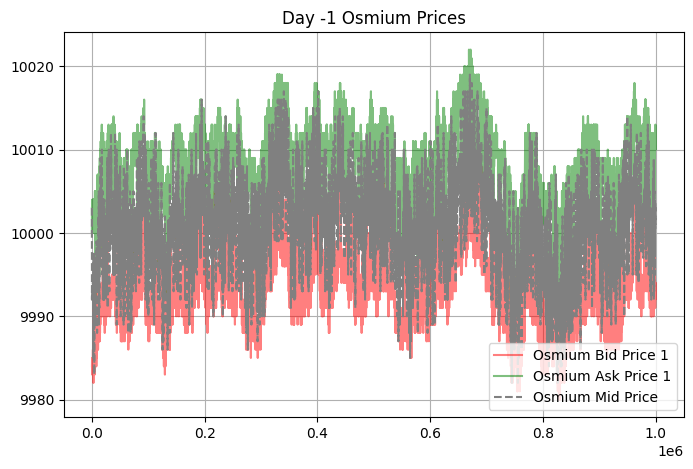

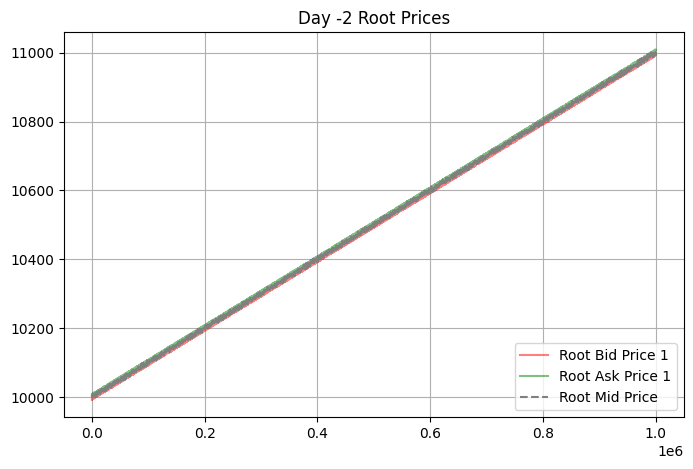

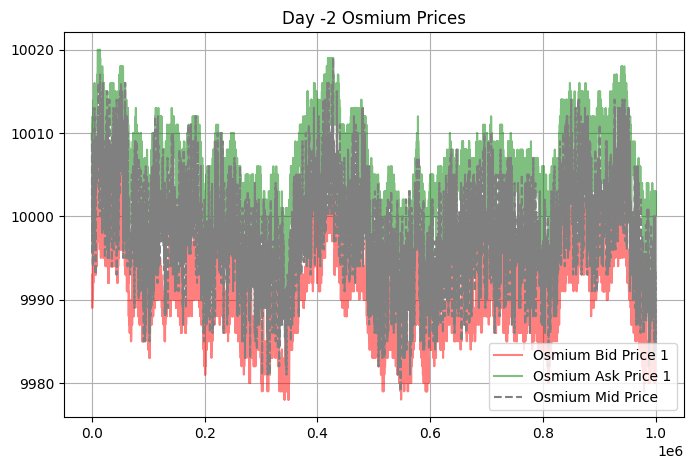

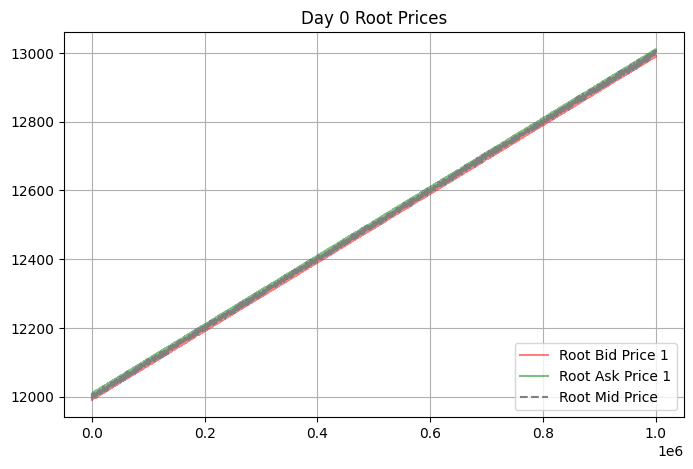

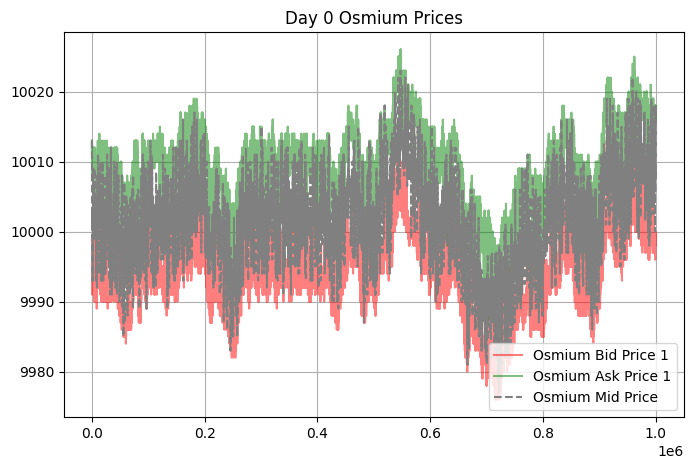

In [64]:
files = {-1: '../Round 1/Data/prices_round_1_day_-1.csv', 
         -2: '../Round 1/Data/prices_round_1_day_-2.csv', 
         0: '../Round 1/Data/prices_round_1_day_0.csv'}

for key, val in files.items():
    get_price_plots(FILENAME=val, day=key)

**Interpreting Plots**

It appears that Osmium shows fixed value behavior, constantly hovering around a mean, which can be confirmed by testing for a unit root. 

The Root displays a consistent upwards linear trend.

In [65]:
from statsmodels.tsa.stattools import adfuller
# Function to organize ADF test results
def adf_test(data):
    keys = ['Test Statistic','p-value','# of Lags','# of Obs']
    values = adfuller(data)
    test = pd.DataFrame.from_dict(dict(zip(keys,values[0:4])),
                                  orient='index',columns=[data.name])
    return test

In [66]:

for val in files.values():
    df = pd.read_csv(val, delimiter=';')
    osmium = df[df['product'] == 'ASH_COATED_OSMIUM']
    price_cols = ['bid_price_1', 'ask_price_1', 'mid_price']
    dummy = osmium.drop(columns=[col for col in osmium.columns if col not in price_cols])
    temp = []
    for column in dummy.columns:
        test = adf_test(dummy[column].dropna())
        temp.append(test)
    results = pd.concat(temp, axis=1)
    display(temp)

[                bid_price_1
 Test Statistic    -4.919715
 p-value            0.000032
 # of Lags         14.000000
 # of Obs        9587.000000,
                 ask_price_1
 Test Statistic    -4.959597
 p-value            0.000027
 # of Lags         17.000000
 # of Obs        9588.000000,
                   mid_price
 Test Statistic  -100.201626
 p-value            0.000000
 # of Lags          0.000000
 # of Obs        9999.000000]

[                bid_price_1
 Test Statistic    -3.797492
 p-value            0.002933
 # of Lags         13.000000
 # of Obs        9573.000000,
                 ask_price_1
 Test Statistic    -3.621613
 p-value            0.005361
 # of Lags         18.000000
 # of Obs        9563.000000,
                   mid_price
 Test Statistic  -100.184597
 p-value            0.000000
 # of Lags          0.000000
 # of Obs        9999.000000]

[                bid_price_1
 Test Statistic    -3.077691
 p-value            0.028249
 # of Lags         21.000000
 # of Obs        9585.000000,
                 ask_price_1
 Test Statistic    -3.325287
 p-value            0.013785
 # of Lags         17.000000
 # of Obs        9593.000000,
                   mid_price
 Test Statistic  -100.095263
 p-value            0.000000
 # of Lags          0.000000
 # of Obs        9999.000000]

ADF Test confirms that the Osmium data is stationary, so that I can proceed with a fixed value reverting strategy

In [96]:
trades_1_2 = pd.read_csv('../Round 1/Data/trades_round_1_day_-2.csv', delimiter=';')
display(trades_1_2)

,timestamp,buyer,seller,symbol,currency,price,quantity
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2
2,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7
3,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8
4,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7
...,...,...,...,...,...,...,...
768,989100,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10980.0,6
769,992000,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9983.0,4
770,994200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10002.0,2
771,995300,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10001.0,6


In [98]:
trades_1_1 = pd.read_csv('../Round 1/Data/trades_round_1_day_-1.csv', delimiter=';')
trades_1_0 = pd.read_csv('../Round 1/Data/trades_round_1_day_0.csv', delimiter=';')

In [116]:
def get_volume_plots(df, day, product): 
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.grid()
    ax.scatter(df['timestamp'], df['price'], s=df['quantity'], alpha=0.5)
    plt.title(f'Price Movement & Trade Size for {product} on day {day}')

    fig, ax = plt.subplots(figsize=(5, 10))
    ax.grid()
    volume_profile = df.groupby('price')['quantity'].sum()
    volume_profile.plot(kind='barh')
    plt.title(f'Volume Profile (Liquidity Zones) for {product} on day {day}')

In [103]:
df_dict = {0: trades_1_0, -1: trades_1_1, -2: trades_1_2}
PRODUCTS = ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']

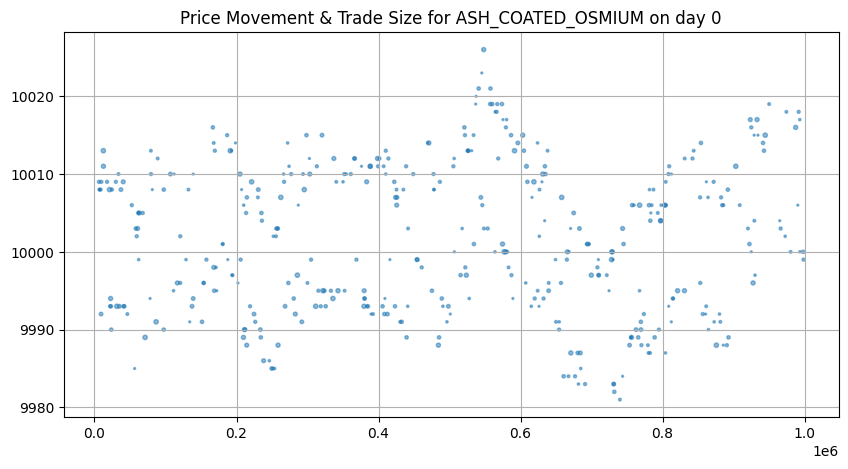

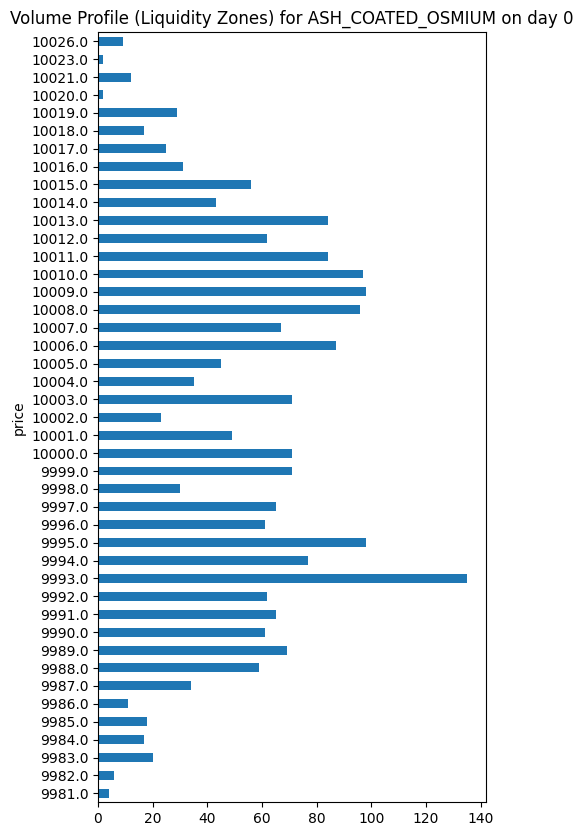

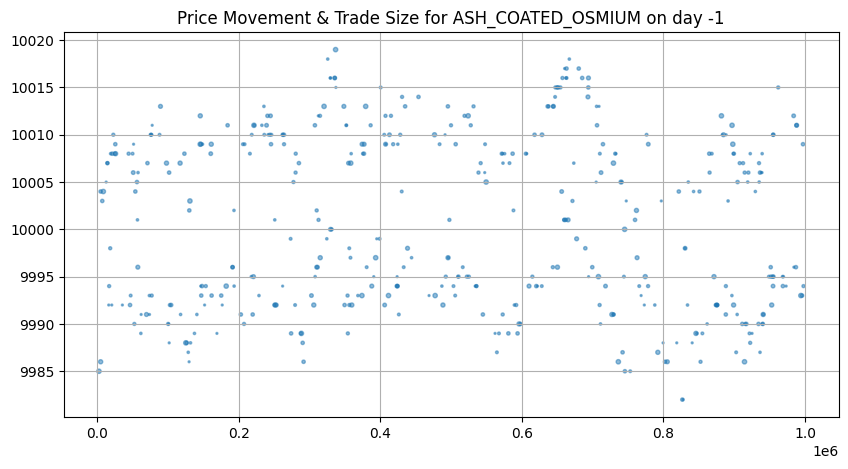

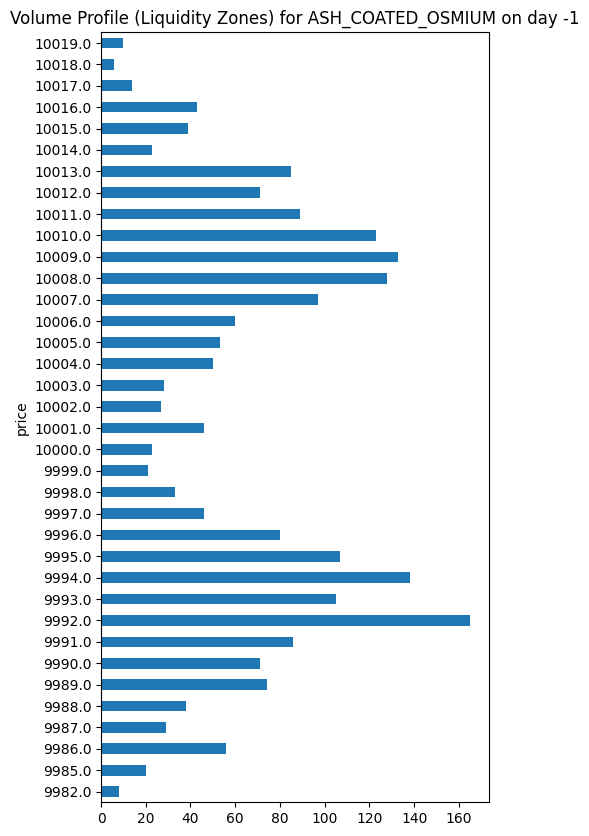

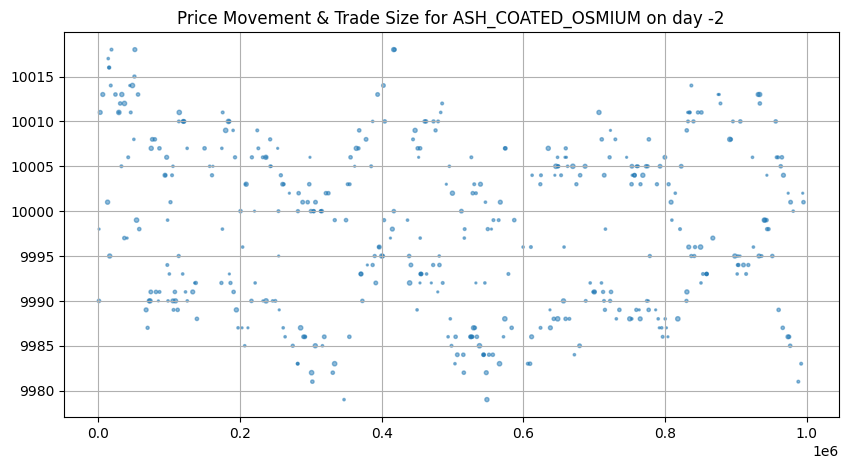

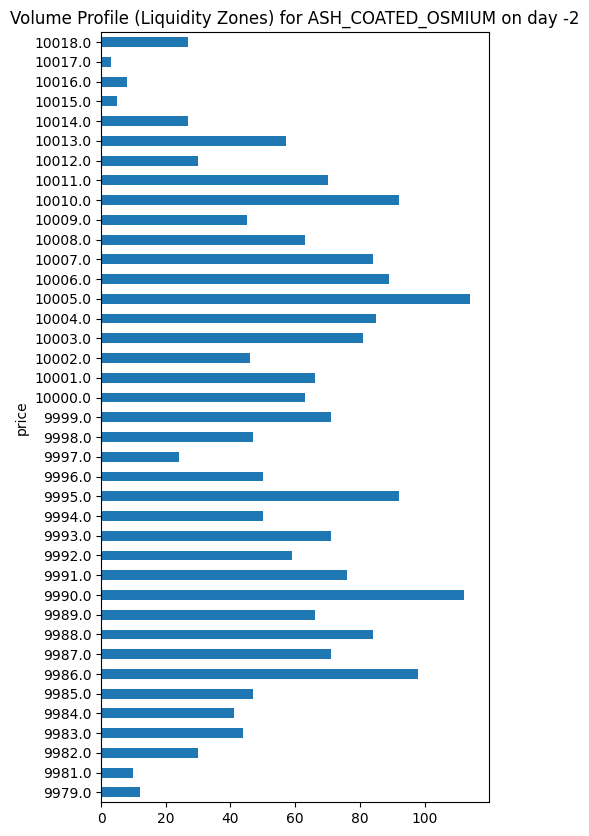

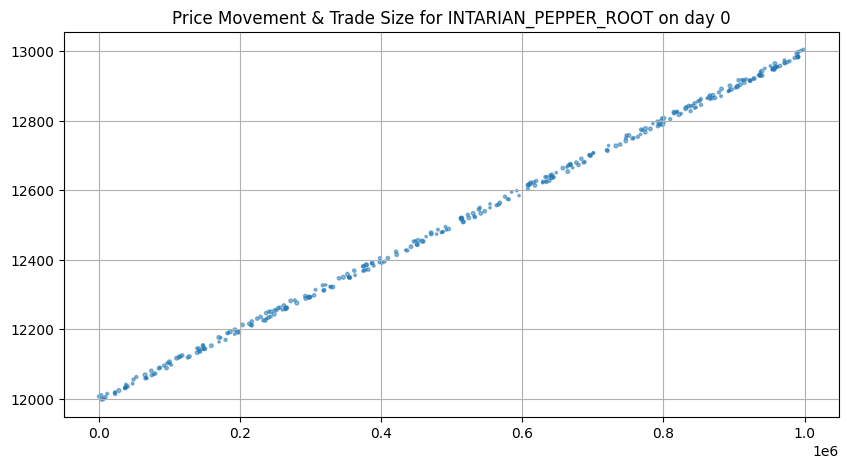

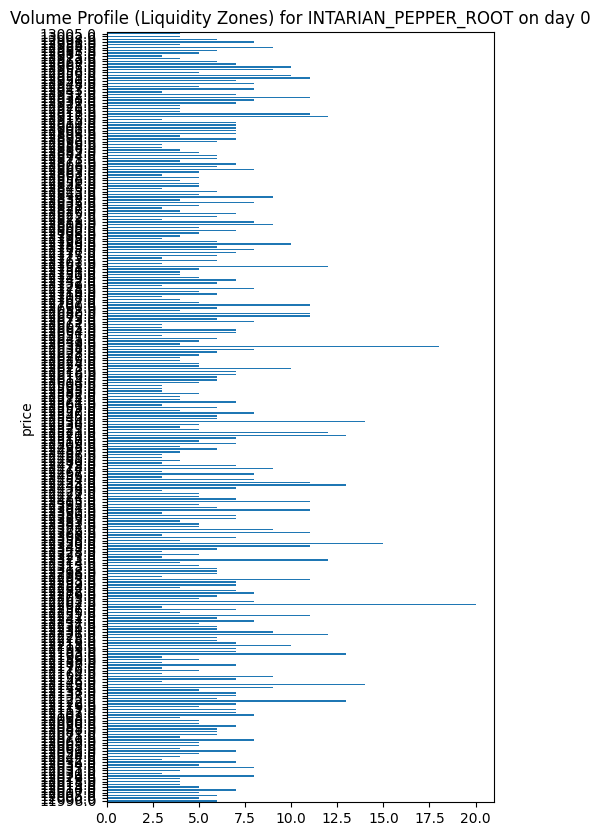

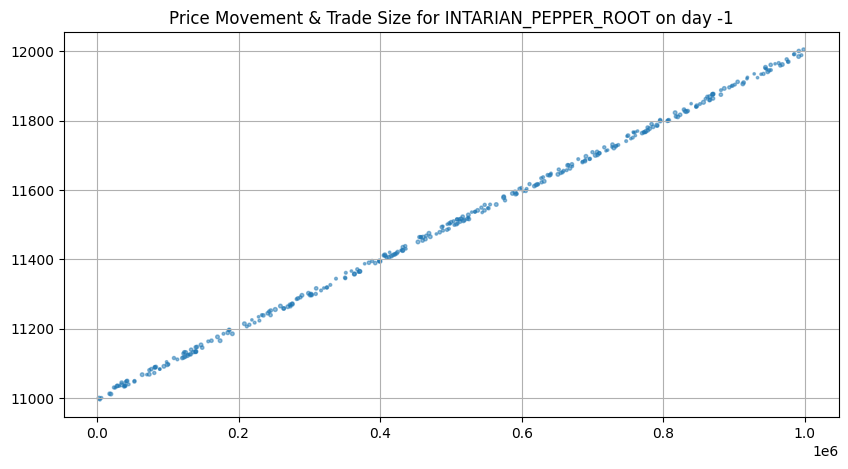

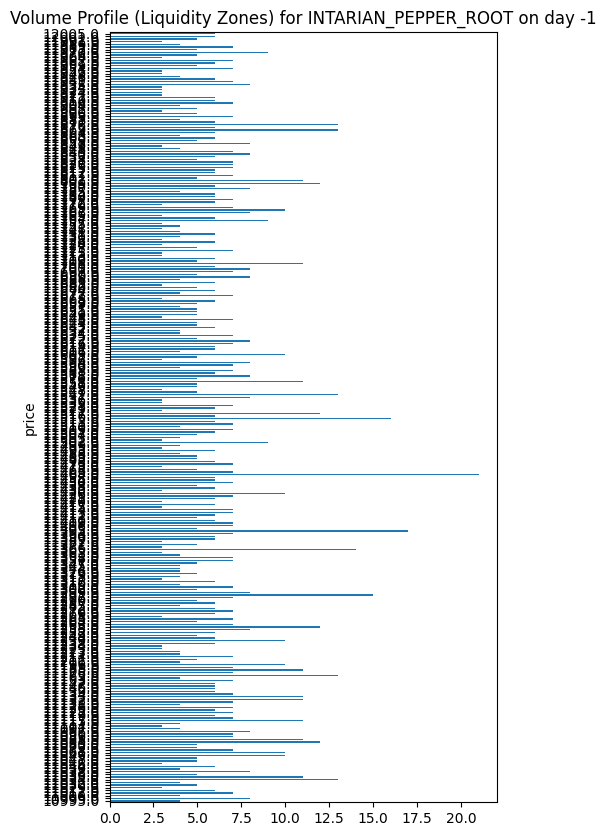

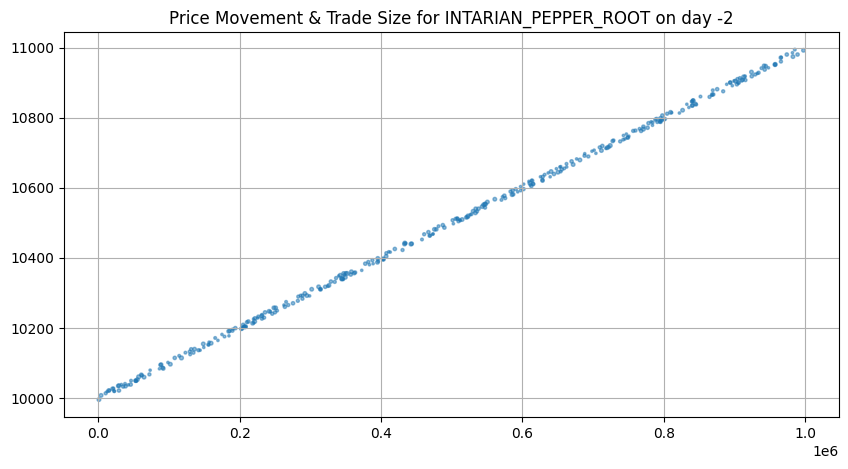

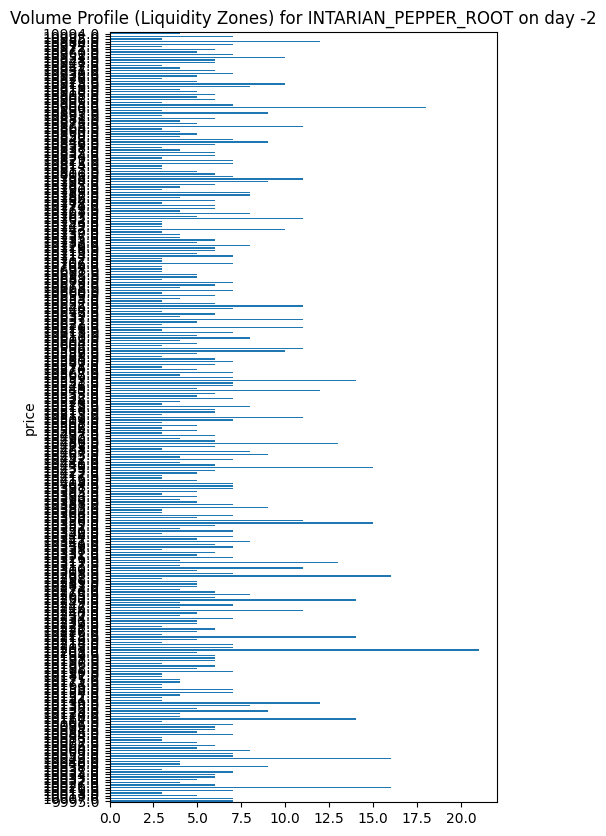

In [117]:
for product in PRODUCTS:
    for key, val in df_dict.items():
        df = val
        get_volume_plots(df[df['symbol'] == product], key, product)

C:\Users\wfpin\AppData\Local\Temp\ipykernel_38340\2879686021.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  osmium[col] = osmium[col].replace(0, pd.NA)
C:\Users\wfpin\AppData\Local\Temp\ipykernel_38340\2879686021.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  osmium[price_cols] = osmium[osmium.columns.intersection(price_cols)].ffill()
C:\Users\wfpin\AppData\Local\Temp\ipykernel_38340\2879686021.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

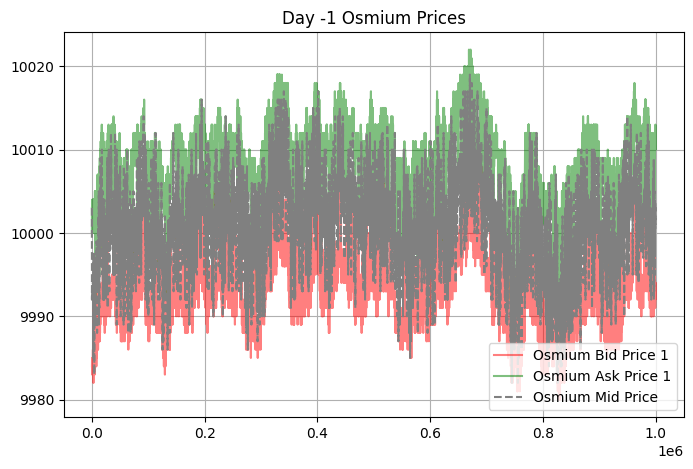

In [ ]:
df = pd.read_csv('../Round 1/Data/prices_round_1_day_-1.csv', delimiter=';')
osmium = df[df['product'] == 'ASH_COATED_OSMIUM']

price_cols = ['bid_price_1', 'ask_price_1', 'mid_price']
# for col in price_cols:
#     osmium[col] = osmium[col].replace(0, pd.NA)

# osmium[price_cols] = osmium[osmium.columns.intersection(price_cols)].ffill()

fig, ax = plt.subplots(figsize=(8, 5))
plt.title('Day -1 Osmium Prices')
ax.grid()
ax.plot(osmium['timestamp'], osmium['bid_price_1'], color='red', label='Osmium Bid Price 1', alpha=0.5)

ax.plot(osmium['timestamp'], osmium['ask_price_1'], color='green', label='Osmium Ask Price 1', alpha=0.5)

ax.plot(osmium['timestamp'], osmium['mid_price'], linestyle='dashed', color='grey', label='Osmium Mid Price')
plt.legend(loc='lower right')